# Day 2 — Machine Learning
### Enterprise HR AI — Workforce Intelligence & Upskilling Platform

## Project Overview

Day 1 understood, validated, cleaned, and connected the raw HR data. Today builds on
that clean, trusted foundation to answer the first real business question: **who is
at risk of leaving?**

The rule for today, carried over from the project notes: don't jump straight to the
fanciest model. Build a boring, explainable baseline first, only then compare it
against stronger models, explain *why* the winner makes its predictions, and version
it properly so every prediction can be traced back to the exact model that made it.

**What this notebook does, in order:**

| Step | Section | What it answers |
|------|---------|------------------|
| 5 | Feature Engineering | Turn the cleaned Day 1 tables into a model-ready feature set |
| 6 | Baseline Model | How well does a simple, explainable Logistic Regression do? |
| 7 | Model Comparison | Does a more complex model (Random Forest / XGBoost) actually do better, and by how much? |
| 8 | Model Explainability (SHAP) | *Why* does the winning model flag who it flags? |
| 9 | Model Versioning | Save the winning model so every prediction is traceable to a specific version |


## 0. Setup

### 0.1 Importing Libraries

Everything today needs: `pandas`/`numpy` for data handling, `matplotlib` for charts,
`scikit-learn` for preprocessing/modelling/metrics, `xgboost` for the strongest
tabular model in the comparison, `shap` for explainability, and `joblib` for saving
the final pipeline.

In [1]:
import os
import json
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
)
import xgboost as xgb
import shap
import joblib

# Show every column when printing a DataFrame, instead of truncating with '...'
pd.set_option("display.max_columns", None)

# Same seed as Day 1, so everything here is reproducible too
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 0.2 Project Folder Structure

Picking up the same folders Day 1 set up, plus one new one for today's output —
`models/`, sitting right alongside `data/` and this notebook, so trained models
live next to (not inside) the data they were trained on.

In [2]:
BASE = "."  # this notebook lives at the project root, next to Day 1
PROCESSED_PATH = f"{BASE}/data/processed"
MODELS_PATH = f"{BASE}/models"

os.makedirs(MODELS_PATH, exist_ok=True)

print("Looking for Day 1's processed files in:", PROCESSED_PATH)
print("Found:", os.listdir(PROCESSED_PATH))

Looking for Day 1's processed files in: ./data/processed
Found: ['career_path_intelligence.csv', 'employee_attrition_processed.csv', 'employee_intelligence.csv', 'engagement_processed.csv', 'essential_skills_processed.csv', 'occupation_master.csv', 'org_skill_heatmap.csv', 'software_skills_processed.csv']


### 0.3 Loading Day 1's Processed Data

Today starts from the **cleaned** files Day 1 saved to `data/processed/`, not the
raw CSVs — no point re-doing yesterday's work, and no point risking yesterday's
messiness leaking into a model. If these files aren't there, Day 1's notebook needs
to be run first; that's a hard requirement, not a nice-to-have, since everything
below assumes the data is already validated and clean.

In [3]:
REQUIRED_FILES = ["employee_attrition_processed.csv", "engagement_processed.csv"]
missing = [f for f in REQUIRED_FILES if not os.path.exists(f"{PROCESSED_PATH}/{f}")]
assert not missing, (
    f"Missing processed file(s): {missing}. Run Day1_Data_Foundation.ipynb first -- "
    "Day 2 builds directly on its cleaned output, not the raw CSVs."
)

attrition = pd.read_csv(f"{PROCESSED_PATH}/employee_attrition_processed.csv")
engagement = pd.read_csv(f"{PROCESSED_PATH}/engagement_processed.csv")

print("employee_attrition_processed:", attrition.shape)
print("engagement_processed:", engagement.shape)
attrition.head()

employee_attrition_processed: (600, 13)
engagement_processed: (600, 5)


,EmployeeID,Age,Department,JobRole,MonthlyIncome,DistanceFromHome,YearsAtCompany,YearsSinceLastPromotion,NumCompaniesWorked,JobSatisfaction,WorkLifeBalance,OverTime,Attrition
0,1,43.0,IT,Sales Executive,6947.0,21,1,1,6,1.0,1.0,No,Yes
1,2,47.0,IT,Research Scientist,6285.5,25,6,1,6,2.0,1.0,No,Yes
2,3,33.0,IT,Software Engineer,7944.0,22,2,2,5,2.0,2.0,Yes,Yes
3,4,47.0,Research & Development,Software Engineer,8777.0,28,1,0,3,3.0,2.0,Yes,Yes
4,5,38.0,IT,Software Engineer,8876.0,24,1,1,0,1.0,3.0,Yes,Yes


---

## 5. Feature Engineering

Turning the cleaned columns into a model-ready feature set: merge in the engagement
data, engineer a handful of features that each have an actual reason to exist
(not just "it seemed interesting"), encode categoricals, and set numeric features
up to be scaled inside the modelling pipeline.

### 5.1 Merging Attrition + Engagement

Day 1's relationship check confirmed `EmployeeID` refers to the same employees in
both files, one-to-one — so this merge is safe. `validate="one_to_one"` makes that
assumption explicit: pandas raises an error instead of silently duplicating rows if
it ever stops being true.

In [4]:
df = attrition.merge(
    engagement, on="EmployeeID", how="left", validate="one_to_one"
)

print("Merged shape:", df.shape)
print("\nMissing values after merge:")
print(df.isnull().sum().sort_values(ascending=False).head(10))
df.head()

Merged shape: (600, 17)

Missing values after merge:
EmployeeID                 0
Age                        0
Department                 0
JobRole                    0
MonthlyIncome              0
DistanceFromHome           0
YearsAtCompany             0
YearsSinceLastPromotion    0
NumCompaniesWorked         0
JobSatisfaction            0
dtype: int64


,EmployeeID,Age,Department,JobRole,MonthlyIncome,DistanceFromHome,YearsAtCompany,YearsSinceLastPromotion,NumCompaniesWorked,JobSatisfaction,WorkLifeBalance,OverTime,Attrition,EngagementScore,PerformanceRating,ManagerRating,TrainingHoursLastYear
0,1,43.0,IT,Sales Executive,6947.0,21,1,1,6,1.0,1.0,No,Yes,81,3.0,3,28
1,2,47.0,IT,Research Scientist,6285.5,25,6,1,6,2.0,1.0,No,Yes,61,2.0,1,8
2,3,33.0,IT,Software Engineer,7944.0,22,2,2,5,2.0,2.0,Yes,Yes,60,4.0,5,38
3,4,47.0,Research & Development,Software Engineer,8777.0,28,1,0,3,3.0,2.0,Yes,Yes,59,1.0,3,39
4,5,38.0,IT,Software Engineer,8876.0,24,1,1,0,1.0,3.0,Yes,Yes,67,2.0,3,2


### 5.2 Engineered Features

Four new features, each with an actual reason (per the project note: no feature
without a reason):

| Feature | Formula | Why it might matter |
|---------|---------|----------------------|
| `IncomePerYear` | `MonthlyIncome * 12 / YearsAtCompany` | Pay relative to tenure — a long-tenured employee on a low salary is a different risk profile than a new hire on the same salary |
| `PromotionGapRatio` | `YearsSinceLastPromotion / YearsAtCompany` | Normalizes "time since promotion" by how long they've actually been there, so a 2-year gap means something different for a 3-year vs a 15-year employee |
| `OverallSatisfaction` | `(JobSatisfaction + WorkLifeBalance) / 2` | A single combined signal from two correlated 1–4 scales |
| `ExperienceRatio` | `YearsAtCompany / (NumCompaniesWorked + 1)` | Loyalty/stability signal — high tenure relative to a low job-hopping history |

`.replace(0, 1)` on the denominators avoids a division-by-zero for employees with
`YearsAtCompany == 0` (i.e. brand new hires); it treats "0 years" the same as "1
year" for these ratios rather than producing `inf`.

In [5]:
df["IncomePerYear"] = df["MonthlyIncome"] * 12 / df["YearsAtCompany"].replace(0, 1)
df["PromotionGapRatio"] = df["YearsSinceLastPromotion"] / df["YearsAtCompany"].replace(0, 1)
df["OverallSatisfaction"] = (df["JobSatisfaction"] + df["WorkLifeBalance"]) / 2
df["ExperienceRatio"] = df["YearsAtCompany"] / (df["NumCompaniesWorked"] + 1)

engineered_cols = ["IncomePerYear", "PromotionGapRatio", "OverallSatisfaction", "ExperienceRatio"]
df[engineered_cols].describe()

,IncomePerYear,PromotionGapRatio,OverallSatisfaction,ExperienceRatio
count,600.000000,600.000000,600.000000,600.000000
mean,38318.483155,0.399764,2.517500,1.502563
std,37340.763052,0.396119,0.802819,2.280370
min,720.000000,0.000000,1.000000,0.000000
25%,9621.000000,0.000000,2.000000,0.166667
50%,22590.750000,0.333333,2.500000,0.750000
75%,60012.000000,0.750000,3.000000,2.000000
max,196200.000000,1.000000,4.000000,17.000000


### 5.3 Checking for Leakage

A leaky feature is one that's basically a disguised version of the answer — it would
make the model look great on paper and useless in production, because that
information wouldn't exist yet at prediction time. None of Day 1's columns describe
*why* or *whether* someone already left, so there's nothing to remove on that front.

`EmployeeID` is dropped for a different reason: it's not leaky, it's just an
arbitrary label with no predictive meaning, and a model could otherwise "memorize"
individual IDs instead of learning general patterns.

In [6]:
ID_COL = "EmployeeID"
TARGET_COL = "Attrition"

print(f"Dropping '{ID_COL}' from the feature set (arbitrary identifier, not a leak).")
print(f"Target column: '{TARGET_COL}' -- everything else is a candidate feature.")

Dropping 'EmployeeID' from the feature set (arbitrary identifier, not a leak).
Target column: 'Attrition' -- everything else is a candidate feature.


### 5.4 Defining Features (X) and Target (y)

The target is binarized (`Yes` → `1`, `No` → `0`) so it works directly with
scikit-learn's classifiers and with `roc_auc_score`/`predict_proba`. Columns are
split into categorical (need encoding) and numeric (need scaling) groups, since
they'll be preprocessed differently in the pipeline below.

In [7]:
y = (df[TARGET_COL] == "Yes").astype(int)

categorical_cols = ["Department", "JobRole", "OverTime"]
numeric_cols = [
    c for c in df.columns
    if c not in categorical_cols + [TARGET_COL, ID_COL]
]

X = df[categorical_cols + numeric_cols]

print(f"Features: {X.shape[1]} columns ({len(categorical_cols)} categorical, {len(numeric_cols)} numeric)")
print(f"Target balance -- Attrition=Yes: {y.mean()*100:.1f}%  |  Attrition=No: {(1-y.mean())*100:.1f}%")
print("\nCategorical:", categorical_cols)
print("Numeric:", numeric_cols)

Features: 19 columns (3 categorical, 16 numeric)
Target balance -- Attrition=Yes: 74.5%  |  Attrition=No: 25.5%

Categorical: ['Department', 'JobRole', 'OverTime']
Numeric: ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany', 'YearsSinceLastPromotion', 'NumCompaniesWorked', 'JobSatisfaction', 'WorkLifeBalance', 'EngagementScore', 'PerformanceRating', 'ManagerRating', 'TrainingHoursLastYear', 'IncomePerYear', 'PromotionGapRatio', 'OverallSatisfaction', 'ExperienceRatio']


### 5.5 Train/Test Split

`stratify=y` keeps the same Yes/No ratio in both the train and test sets — important
here since the target isn't a clean 50/50 split, and a random split could otherwise
leave the test set with too few examples of one class to evaluate reliably. The same
80/20 split and the same `RANDOM_STATE` are reused for every model in Section 7, so
the comparison between models is fair.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Train Attrition=Yes rate: {y_train.mean()*100:.1f}%")
print(f"Test  Attrition=Yes rate: {y_test.mean()*100:.1f}%")

Train: 480 rows  |  Test: 120 rows
Train Attrition=Yes rate: 74.6%
Test  Attrition=Yes rate: 74.2%


### 5.6 The Preprocessing Pipeline

One `ColumnTransformer`, built once and reused for every model below: `OneHotEncoder`
turns each categorical column into 0/1 indicator columns (`handle_unknown="ignore"`
means a category never seen in training won't crash the pipeline at prediction time),
and `StandardScaler` rescales every numeric column to mean 0 / standard deviation 1,
which matters for Logistic Regression in particular since it's sensitive to features
being on very different scales (e.g. `MonthlyIncome` in the thousands vs
`JobSatisfaction` on a 1–4 scale).

Wrapping this in a `Pipeline` (rather than transforming `X` by hand) means the exact
same fitted transformation is guaranteed to be applied at prediction time later —
there's no way to accidentally fit the scaler on the wrong data or apply it
inconsistently.

In [9]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols),
])

preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Department', 'JobRole', 'OverTime']),
                                ('num', StandardScaler(),
                                 ['Age', 'MonthlyIncome', 'DistanceFromHome',
                                  'YearsAtCompany', 'YearsSinceLastPromotion',
                                  'NumCompaniesWorked', 'JobSatisfaction',
                                  'WorkLifeBalance', 'EngagementScore',
                                  'PerformanceRating', 'ManagerRating',
                                  'TrainingHoursLastYear', 'IncomePerYear',
                                  'PromotionGapRatio', 'OverallSatisfaction',
                                  'ExperienceRatio'])])

---

## 6. Baseline Model

### 6.1 Why Logistic Regression First

Logistic Regression, on purpose, before anything fancier. It's fast, its
coefficients are directly interpretable, and — the important part for this project —
it outputs a real probability (`predict_proba`) rather than just a Yes/No label,
which matters because the eventual goal is to bucket employees into risk levels
(e.g. HIGH/MEDIUM/LOW), not just flag them as a binary "will leave / won't leave".

In [10]:
baseline_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline_pipeline.fit(X_train, y_train)
print("Baseline Logistic Regression trained.")

Baseline Logistic Regression trained.


### 6.2 Evaluating the Baseline

Judged on **precision, recall, F1, and ROC-AUC — not accuracy**. Accuracy alone
would be a misleading number here: with the target this imbalanced, a model could
score well on accuracy just by leaning toward the majority class without actually
being useful. Precision/recall/F1 (per-class) and ROC-AUC (threshold-independent)
give a much more honest picture.

In [11]:
baseline_probs = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_preds = baseline_pipeline.predict(X_test)

baseline_auc = roc_auc_score(y_test, baseline_probs)
print(f"ROC-AUC: {baseline_auc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=["No", "Yes"]))

ROC-AUC: 0.8536

              precision    recall  f1-score   support

          No       0.75      0.58      0.65        31
         Yes       0.86      0.93      0.90        89

    accuracy                           0.84       120
   macro avg       0.81      0.76      0.78       120
weighted avg       0.83      0.84      0.83       120



A confusion matrix makes the same numbers easier to read at a glance: how many
of each class the baseline got right vs. mixed up.

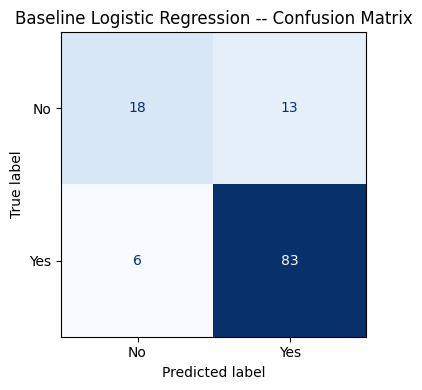

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, baseline_preds)
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Baseline Logistic Regression -- Confusion Matrix")
plt.tight_layout()
plt.show()

### 6.3 Baseline Summary

This number is the one everything in Section 7 has to beat to justify the extra
complexity of a Random Forest or XGBoost.

In [13]:
print("BASELINE SUMMARY\n" + "="*60)
print(f"Model:     Logistic Regression")
print(f"Precision: {precision_score(y_test, baseline_preds):.4f}")
print(f"Recall:    {recall_score(y_test, baseline_preds):.4f}")
print(f"F1:        {f1_score(y_test, baseline_preds):.4f}")
print(f"ROC-AUC:   {baseline_auc:.4f}")

BASELINE SUMMARY
Model:     Logistic Regression
Precision: 0.8646
Recall:    0.9326
F1:        0.8973
ROC-AUC:   0.8536


---

## 7. Model Comparison

### 7.1 Three Models, Same Split

The same train/test split and the same preprocessing pipeline as the baseline —
only the model changes, so any difference in the results is actually attributable
to the model, not to some other accidental difference in setup.

- **Logistic Regression** — the explainable baseline, repeated here for a
  side-by-side comparison
- **Random Forest** — picks up non-linear relationships and feature interactions a
  linear model can't
- **XGBoost** — usually the strongest performer on tabular data like this

In [14]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
}

fitted_pipelines = {}
comparison_rows = []

for name, estimator in candidate_models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    comparison_rows.append({
        "Model": name,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    })
    fitted_pipelines[name] = pipe

print("All three models trained on the identical train/test split.")

All three models trained on the identical train/test split.


### 7.2 The Comparison Table

In [15]:
comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
comparison_df

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.8646,0.9326,0.8973,0.8536
Random Forest,0.8155,0.9438,0.8750,0.7934
XGBoost,0.8081,0.8989,0.8511,0.7688


### 7.3 Visual Comparison

The same table as a grouped bar chart, so the trade-offs between models are
visible at a glance rather than needing to scan numbers column by column.

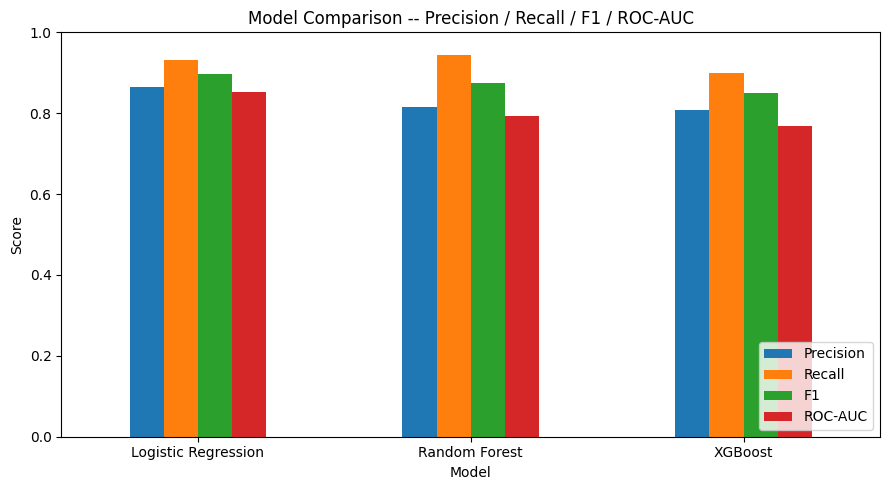

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_df.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison -- Precision / Recall / F1 / ROC-AUC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 7.4 Picking a Winner

Not just the top number on one metric. For attrition specifically, **missing a
genuinely high-risk employee (a false negative) is expensive** — HR never gets the
chance to intervene. A slightly lower precision is an acceptable trade for catching
more real cases, so the winner is picked on **Recall first, F1 as the tie-breaker**
— not on whichever model happens to have the highest ROC-AUC or accuracy.

In [17]:
ranked = comparison_df.sort_values(["Recall", "F1"], ascending=False)
print("Ranked by Recall (tie-break: F1):\n")
print(ranked)

winner_name = ranked.index[0]
winner_pipeline = fitted_pipelines[winner_name]

print(f"\nWinner: {winner_name}")
print(f"  Recall:    {ranked.loc[winner_name, 'Recall']:.4f}")
print(f"  Precision: {ranked.loc[winner_name, 'Precision']:.4f}")
print(f"  F1:        {ranked.loc[winner_name, 'F1']:.4f}")
print(f"  ROC-AUC:   {ranked.loc[winner_name, 'ROC-AUC']:.4f}")

Ranked by Recall (tie-break: F1):

                     Precision  Recall      F1  ROC-AUC
Model                                                  
Random Forest           0.8155  0.9438  0.8750   0.7934
Logistic Regression     0.8646  0.9326  0.8973   0.8536
XGBoost                 0.8081  0.8989  0.8511   0.7688

Winner: Random Forest
  Recall:    0.9438
  Precision: 0.8155
  F1:        0.8750
  ROC-AUC:   0.7934


### 7.5 Saving the Winning Pipeline

The whole pipeline is saved — preprocessing *and* model together, not just the
model — so anything loading this file later can hand it a raw, unprocessed row and
get a correct prediction back, without having to remember to separately re-apply
the same encoding and scaling.

In [18]:
winner_path = f"{MODELS_PATH}/attrition_pipeline.joblib"
joblib.dump(winner_pipeline, winner_path)

print(f"Saved winning pipeline ({winner_name}) to: {winner_path}")

Saved winning pipeline (Random Forest) to: ./models/attrition_pipeline.joblib


---

## 8. Model Explainability (SHAP)

A prediction like "Employee 214 — 82% attrition risk" is useless to an actual HR
person unless the *why* comes with it. SHAP gives two levels of explanation:

- **Global** — what generally drives attrition across the whole company (e.g.
  overtime, low job satisfaction, poor work-life balance), ranked by importance
- **Local** — why *this specific* employee is flagged: their personal top
  contributing factors

### 8.1 Building the Explainer

The explainer type depends on which model won Section 7: `TreeExplainer` for the
tree-based models (Random Forest / XGBoost), or `LinearExplainer` if Logistic
Regression happened to win instead. Either way, SHAP needs the data in its
*already-preprocessed* (one-hot encoded, scaled) form, since that's the actual
numeric input the model sees — so the fitted preprocessor from the winning pipeline
is applied first, and the explanation is built on top of that.

In [19]:
preprocess_step = winner_pipeline.named_steps["preprocess"]
model_step = winner_pipeline.named_steps["model"]

feature_names = preprocess_step.get_feature_names_out()
X_test_transformed = preprocess_step.transform(X_test)
X_test_readable = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

if winner_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(model_step)
else:
    explainer = shap.LinearExplainer(model_step, X_test_transformed)

shap_values = explainer.shap_values(X_test_transformed)

# Newer SHAP versions return one array shaped (n_samples, n_features, n_classes)
# for binary classifiers; older versions return a list of two arrays (one per
# class). Either way, what's wanted here is the "Attrition = Yes" (class 1) view.
if isinstance(shap_values, list):
    shap_values_yes = shap_values[1]
    base_value = explainer.expected_value[1]
elif np.ndim(shap_values) == 3:
    shap_values_yes = shap_values[:, :, 1]
    base_value = explainer.expected_value[1] if np.ndim(explainer.expected_value) else explainer.expected_value
else:
    shap_values_yes = shap_values
    base_value = explainer.expected_value

print(f"Explainer: {type(explainer).__name__} on {winner_name}")
print(f"SHAP values shape: {shap_values_yes.shape}")

Explainer: TreeExplainer on Random Forest
SHAP values shape: (120, 29)


### 8.2 Global View — What Drives Attrition Company-Wide

Each dot is one employee, for one feature. Red = a high value of that feature,
blue = a low value. Position left/right shows whether that feature pushed the
prediction toward "will leave" (right) or "will stay" (left). Features are ranked
top-to-bottom by overall importance.

C:\Users\JSBG\AppData\Local\Temp\ipykernel_13984\814010465.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_yes, X_test_readable, show=False)


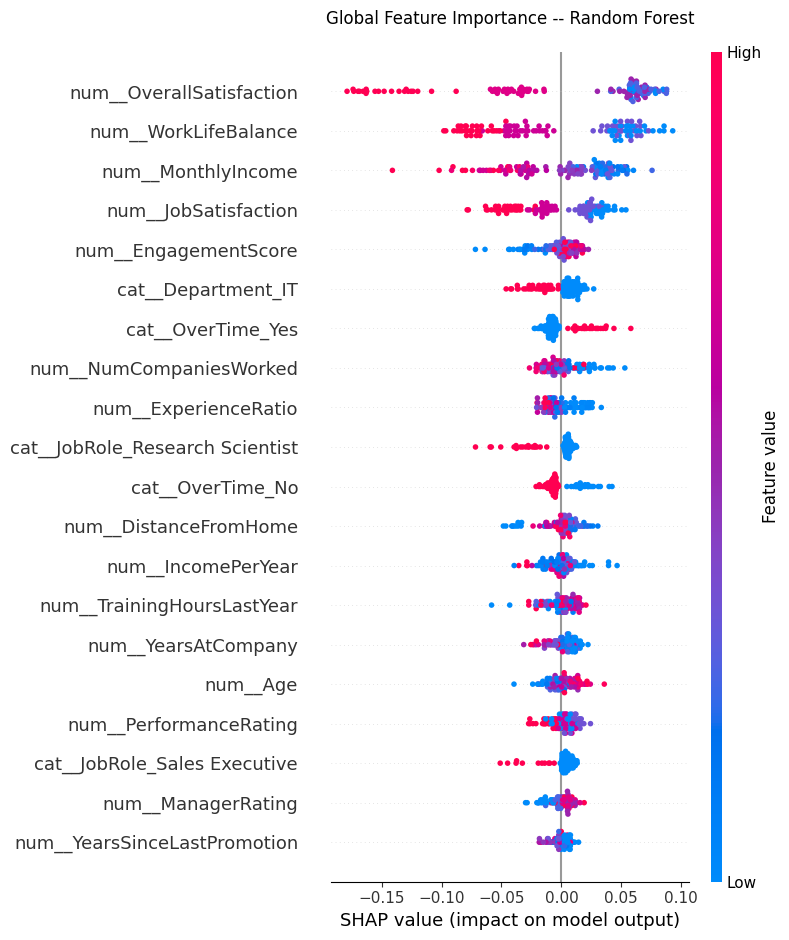

In [20]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values_yes, X_test_readable, show=False)
plt.title(f"Global Feature Importance -- {winner_name}", pad=20)
plt.tight_layout()
plt.show()

### 8.3 Local View — Why One Specific Employee Was Flagged

The same idea, zoomed in on a single row of the test set: which factors pushed
*this employee's* prediction up (red, toward "will leave") or down (blue, toward
"will stay") from the model's average starting point.

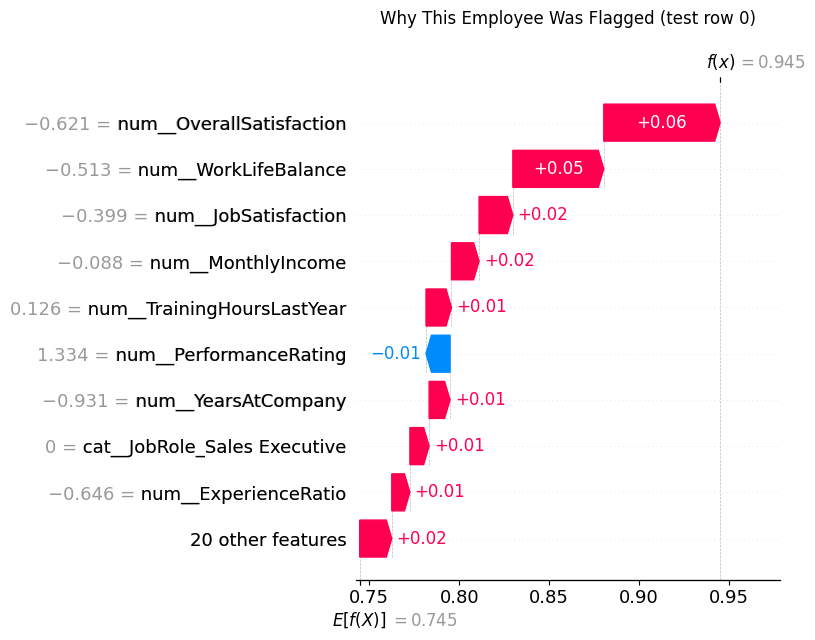

Predicted attrition probability for this employee: 94.5%
Actual label: Yes


In [21]:
employee_idx = 0  # first employee in the test set, as an example
employee_row = X_test.iloc[employee_idx]

local_explanation = shap.Explanation(
    values=shap_values_yes[employee_idx],
    base_values=base_value,
    data=X_test_readable.iloc[employee_idx].values,
    feature_names=feature_names,
)

plt.figure()
shap.plots.waterfall(local_explanation, show=False)
plt.title(f"Why This Employee Was Flagged (test row {employee_idx})", pad=20)
plt.tight_layout()
plt.show()

predicted_prob = winner_pipeline.predict_proba(employee_row.to_frame().T)[0, 1]
print(f"Predicted attrition probability for this employee: {predicted_prob*100:.1f}%")
print(f"Actual label: {'Yes' if y_test.iloc[employee_idx] == 1 else 'No'}")

### 8.4 Top Global Drivers, in Plain Text

The same global ranking as Section 8.2, but as a short printed list — easier to
drop straight into a report or a dashboard tooltip than a screenshot of a chart.

In [22]:
mean_abs_shap = pd.Series(
    np.abs(shap_values_yes).mean(axis=0), index=feature_names
).sort_values(ascending=False)

print("TOP 10 DRIVERS OF ATTRITION (by mean |SHAP value|)\n" + "="*60)
for i, (feature, value) in enumerate(mean_abs_shap.head(10).items(), start=1):
    print(f"  {i:>2}. {feature:<40} {value:.4f}")

TOP 10 DRIVERS OF ATTRITION (by mean |SHAP value|)
   1. num__OverallSatisfaction                 0.0729
   2. num__WorkLifeBalance                     0.0536
   3. num__MonthlyIncome                       0.0363
   4. num__JobSatisfaction                     0.0300
   5. num__EngagementScore                     0.0124
   6. cat__Department_IT                       0.0123
   7. cat__OverTime_Yes                        0.0122
   8. num__NumCompaniesWorked                  0.0117
   9. num__ExperienceRatio                     0.0111
  10. cat__JobRole_Research Scientist          0.0106


---

## 9. Model Versioning + MLflow

### 9.1 Why Manual Versioning First

Simple versioning, before reaching for a whole platform. Every time a new model is
trained, it gets its own numbered folder with metadata attached, so any prediction
can always be traced back to exactly which model made it — which model file, which
metrics it had, and when it was trained.

`next_version` looks at what's already in `models/` and picks the next number, so
re-running this notebook doesn't silently overwrite a previous version.

In [23]:
existing_versions = sorted([
    d for d in os.listdir(MODELS_PATH)
    if d.startswith("v") and os.path.isdir(f"{MODELS_PATH}/{d}") and d[1:].isdigit()
])
next_version = f"v{len(existing_versions) + 1}"
version_path = f"{MODELS_PATH}/{next_version}"
os.makedirs(version_path, exist_ok=True)

print(f"Existing versions: {existing_versions or '(none yet)'}")
print(f"Saving this model as: {next_version}")

Existing versions: ['v1', 'v2']
Saving this model as: v3


### 9.2 Saving the Model + Metadata

Both go in the same version folder: the actual pipeline file (`.joblib`), and a
`metadata.json` recording what it is, how it was trained, and how well it did — the
same fields the project's metadata format uses, so this could later feed straight
into a model registry table.

In [24]:
joblib.dump(winner_pipeline, f"{version_path}/attrition_pipeline.joblib")

metadata = {
    "model_name": "Attrition Prediction Model",
    "version": f"{next_version}.0",
    "algorithm": winner_name,
    "training_date": datetime.now().strftime("%Y-%m-%d"),
    "random_state": RANDOM_STATE,
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "n_features": int(X.shape[1]),
    "precision": round(float(ranked.loc[winner_name, "Precision"]), 4),
    "recall": round(float(ranked.loc[winner_name, "Recall"]), 4),
    "f1_score": round(float(ranked.loc[winner_name, "F1"]), 4),
    "roc_auc": round(float(ranked.loc[winner_name, "ROC-AUC"]), 4),
}

with open(f"{version_path}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {version_path}:")
print(f"  - attrition_pipeline.joblib")
print(f"  - metadata.json")

Saved to ./models/v3:
  - attrition_pipeline.joblib
  - metadata.json


### 9.3 Reading It Back

A quick sanity check that the saved version is complete and loads correctly —
proving the save actually worked, rather than assuming it did.

In [25]:
with open(f"{version_path}/metadata.json") as f:
    saved_metadata = json.load(f)

reloaded_pipeline = joblib.load(f"{version_path}/attrition_pipeline.joblib")
reload_check_preds = reloaded_pipeline.predict(X_test)

print(json.dumps(saved_metadata, indent=2))
print(f"\nReloaded pipeline predicts on the test set without error: "
      f"{len(reload_check_preds)} predictions produced.")
assert (reload_check_preds == winner_pipeline.predict(X_test)).all(), \
    "Reloaded model's predictions don't match the original -- save/load mismatch."
print("Reloaded predictions match the original pipeline exactly.")

{
  "model_name": "Attrition Prediction Model",
  "version": "v3.0",
  "algorithm": "Random Forest",
  "training_date": "2026-09-01",
  "random_state": 42,
  "train_rows": 480,
  "test_rows": 120,
  "n_features": 19,
  "precision": 0.8155,
  "recall": 0.9438,
  "f1_score": 0.875,
  "roc_auc": 0.7934
}

Reloaded pipeline predicts on the test set without error: 120 predictions produced.
Reloaded predictions match the original pipeline exactly.




Reloaded pipeline predicts on the test set without error: 120 predictions produced.
Reloaded predictions match the original pipeline exactly.


### 9.4 Note on MLflow

This manual `v1/`, `v2/`, ... + `metadata.json` approach is fine for now, and is
deliberately simple so it doesn't get in the way. Once training more model
versions by hand starts to feel like it's holding the project back, MLflow is the
natural next step — it tracks every run's parameters, metrics, and artifacts
automatically instead of hand-writing JSON files. Not needed yet; the manual
version above already gives full traceability for the MVP.

In [28]:
## 9.5 Performance Trend Prediction (Bonus Model)

rating_gap = df["ManagerRating"] - df["PerformanceRating"]

# Widened thresholds: since both ratings are whole numbers, a gap of exactly 0
# is too narrow a target to be learnable. |gap| <= 1 now counts as "close enough"
# to call Stable; only a gap of 2+ counts as a real divergence.
def trend_label(gap):
    if gap >= 2:
        return "Improving"
    if gap <= -2:
        return "Declining"
    return "Stable"

df["PerformanceTrend"] = rating_gap.apply(trend_label)
print("Label distribution:")
print(df["PerformanceTrend"].value_counts())

majority_baseline = df["PerformanceTrend"].value_counts(normalize=True).max()
print(f"\nMajority-class baseline (always guess the biggest class): {majority_baseline*100:.1f}%")
print("Any real model needs to beat this number to be worth using.")

trend_categorical_cols = ["Department", "JobRole", "OverTime"]
trend_numeric_cols = [c for c in numeric_cols if c not in ["PerformanceRating", "ManagerRating"]]

X_trend = df[trend_categorical_cols + trend_numeric_cols]
y_trend = df["PerformanceTrend"]

X_trend_train, X_trend_test, y_trend_train, y_trend_test = train_test_split(
    X_trend, y_trend, test_size=0.2, stratify=y_trend, random_state=RANDOM_STATE
)

trend_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), trend_categorical_cols),
    ("num", StandardScaler(), trend_numeric_cols),
])

# Compare a couple of reasonable candidates instead of committing to one blind --
# picked on macro-F1 (treats all 3 classes equally, unlike accuracy which
# rewards ignoring small classes).
from sklearn.metrics import f1_score

candidates = {
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "RandomForest (balanced)": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "LogisticRegression (balanced)": LogisticRegression(max_iter=1000, class_weight="balanced"),
}

trend_results = {}
fitted_trend_pipelines = {}
for name, clf in candidates.items():
    pipe = Pipeline([("preprocess", trend_preprocessor), ("model", clf)])
    pipe.fit(X_trend_train, y_trend_train)
    preds = pipe.predict(X_trend_test)
    macro_f1 = f1_score(y_trend_test, preds, average="macro")
    acc = (preds == y_trend_test).mean()
    trend_results[name] = {"macro_F1": macro_f1, "accuracy": acc}
    fitted_trend_pipelines[name] = pipe

trend_comparison = pd.DataFrame(trend_results).T.sort_values("macro_F1", ascending=False)
print("\nModel comparison (sorted by macro-F1):")
print(trend_comparison)
print(f"\n(Majority baseline accuracy for reference: {majority_baseline*100:.1f}%)")

trend_winner_name = trend_comparison.index[0]
trend_pipeline = fitted_trend_pipelines[trend_winner_name]
print(f"\nWinner: {trend_winner_name}")
print("\n" + classification_report(y_trend_test, trend_pipeline.predict(X_trend_test)))

trend_model_path = f"{MODELS_PATH}/performance_trend_pipeline.joblib"
joblib.dump(trend_pipeline, trend_model_path)
print(f"Saved winning trend pipeline ({trend_winner_name}) to: {trend_model_path}")

Label distribution:
PerformanceTrend
Stable       333
Improving    178
Declining     89
Name: count, dtype: int64

Majority-class baseline (always guess the biggest class): 55.5%
Any real model needs to beat this number to be worth using.

Model comparison (sorted by macro-F1):
                               macro_F1  accuracy
LogisticRegression (balanced)  0.324939  0.350000
RandomForest                   0.317344  0.558333
RandomForest (balanced)        0.278976  0.541667

(Majority baseline accuracy for reference: 55.5%)

Winner: LogisticRegression (balanced)

              precision    recall  f1-score   support

   Declining       0.18      0.39      0.25        18
   Improving       0.26      0.28      0.27        36
      Stable       0.57      0.38      0.45        66

    accuracy                           0.35       120
   macro avg       0.34      0.35      0.32       120
weighted avg       0.42      0.35      0.37       120

Saved winning trend pipeline (LogisticRegression 

---

## End of Day 2 — Summary

What's in hand at the end of today, per the project checklist.

In [26]:
print("DAY 2 COMPLETE\n" + "="*60)

print(f"\n5. Feature Engineering -- {X.shape[1]} features built from {df.shape[0]} employees")
print(f"   ({len(categorical_cols)} categorical, {len(numeric_cols)} numeric, "
      f"including {len(engineered_cols)} engineered)")

print(f"\n6. Baseline Model -- Logistic Regression, ROC-AUC {baseline_auc:.4f}")

print(f"\n7. Model Comparison -- {len(comparison_df)} models compared, winner: {winner_name}")
print(ranked.to_string())
print(f"   Saved to: {MODELS_PATH}/attrition_pipeline.joblib")

print(f"\n8. Model Explainability -- SHAP global + local explanations generated")
print(f"   Top driver: {mean_abs_shap.index[0]}")

print(f"\n9. Model Versioning -- saved as {next_version}, metadata logged and verified")
print(f"   Location: {version_path}")

print("\nReady for Day 3 (Workforce Intelligence) -- engagement analytics, role")
print("intelligence, and the skill-gap engine start from here.")

DAY 2 COMPLETE

5. Feature Engineering -- 19 features built from 600 employees
   (3 categorical, 16 numeric, including 4 engineered)

6. Baseline Model -- Logistic Regression, ROC-AUC 0.8536

7. Model Comparison -- 3 models compared, winner: Random Forest
                     Precision  Recall      F1  ROC-AUC
Model                                                  
Random Forest           0.8155  0.9438  0.8750   0.7934
Logistic Regression     0.8646  0.9326  0.8973   0.8536
XGBoost                 0.8081  0.8989  0.8511   0.7688
   Saved to: ./models/attrition_pipeline.joblib

8. Model Explainability -- SHAP global + local explanations generated
   Top driver: num__OverallSatisfaction

9. Model Versioning -- saved as v3, metadata logged and verified
   Location: ./models/v3

Ready for Day 3 (Workforce Intelligence) -- engagement analytics, role
intelligence, and the skill-gap engine start from here.
